In [2]:
import sys
import os
from pathlib import Path
import random
import pandas as pd
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
from pathlib import Path
from sklearn.decomposition import PCA

# Add source directory to path
sys.path.append(os.path.abspath("../src"))

# Import project utilities
from abstractionssymh.debug_utils import debug_info, debug_error, debug_success
from abstractionssymh.data_loader import parse_json_to_dsl
from abstractionssymh.plot_utils import plot_dsl_with_k3d, plot_dsl_with_matplotlib
from abstractionssymh.dsl_utils import collect_singleton_and_pair_data
from abstractionssymh.abstraction_utils import find_abstractions, Abstraction, integrate_abstractions

In [3]:
from datetime import datetime

# --- Set Project Paths ---
current_path = Path.cwd()
base_project_dir = current_path.parent
dataset_directory = base_project_dir / "src" / "abstractionssymh" / "dataset"

# Create a timestamp in human-readable format
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Append timestamp to the folder name
saved_directory = base_project_dir / "src" / "abstractionssymh" / f"saved_{timestamp}"
saved_directory.mkdir(parents=True, exist_ok=True)

debug_info("Current notebook location:", current_path)
debug_info("Base project directory:", base_project_dir)
debug_info("Target dataset directory:", dataset_directory)
debug_info("Saved directory:", saved_directory)

[INFO] Current notebook location: c:\Users\Amogh\abstraction-discovery\notebookssymh
[INFO] Base project directory: c:\Users\Amogh\abstraction-discovery
[INFO] Target dataset directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\dataset
[INFO] Saved directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved_2025-09-29_03-18-26


In [3]:
# # --- Load Chair DSL ---
# chair_directory = dataset_directory / Path("Chair")
# json_files = sorted(chair_directory.glob("*.json"))

# debug_error("No JSON files found in:", chair_directory) if not json_files else None

# use_random = False
# file_path = random.choice(json_files) if use_random else json_files[0]

# debug_success("Loading chair file:", file_path)

# json_content = file_path.read_text(encoding="utf-8")
# dsl_object = parse_json_to_dsl(json_content)

# debug_success("Successfully parsed DSL object")
# debug_info(dsl_object)

In [4]:
# # --- Plot Chair DSL ---
# debug_error("No DSL object to plot.") if dsl_object is None else None

# debug_info("Rendering DSL object with k3d...")
# try:
#     plot_dsl_with_k3d(dsl_object)
#     debug_success("Plotting complete.")
# except Exception as e:
#     debug_error("Failed to plot DSL object:", e)

In [5]:
chair_directory = dataset_directory / "Chair"
json_files = sorted(chair_directory.glob("*.json"))

all_dsl_shapes = {}

# 1. Load all DSL objects and initialize their data structures
print("--- Step 1: Loading DSL objects from JSON files ---")
for json_file in json_files[:1000]: # Using a subset for faster demonstration
    try:
        json_content = json_file.read_text(encoding="utf-8")
        dsl_obj = parse_json_to_dsl(json_content)
        all_dsl_shapes[json_file.name] = {
            "dsl": dsl_obj,
            "singleton_params": {}, # Will be populated next
            "pair_params": {},      # Will be populated next
        }
    except Exception as e:
        debug_error(f"Failed to load {json_file.name}: {e}")
debug_success(f"Loaded {len(all_dsl_shapes)} DSL shapes into memory.")

--- Step 1: Loading DSL objects from JSON files ---
[SUCCESS] Loaded 1000 DSL shapes into memory.


In [6]:
# 2. Collect and store the parameters for each individual shape
print("\n--- Step 2: Collecting parameters for each shape ---")
for name, data in all_dsl_shapes.items():
    dsl_obj = data["dsl"]
    # The [dsl_obj] is important as the function expects a list
    singletons, pairs = collect_singleton_and_pair_data([dsl_obj])
    data["singleton_params"] = singletons
    data["pair_params"] = pairs
debug_success("Populated singleton and pair parameters for each shape.")


--- Step 2: Collecting parameters for each shape ---
[SUCCESS] Collected keys: dict_keys(['Scale', 'Rotate', 'Translate']) singletons, dict_keys(['Scale(Box)', 'Rotate(Scale)', 'Translate(Rotate)', 'Union(Translate)']) pairs
[SUCCESS] Collected parameters: 3 singletons, 4 pairs
[SUCCESS] Collected keys: dict_keys(['Scale', 'Rotate', 'Translate', 'SymRef']) singletons, dict_keys(['Scale(Box)', 'Rotate(Scale)', 'Translate(Rotate)', 'Union(Translate)', 'SymRef(Union)', 'Union(SymRef)', 'SymRef(Translate)']) pairs
[SUCCESS] Collected parameters: 4 singletons, 7 pairs
[SUCCESS] Collected keys: dict_keys(['Scale', 'Rotate', 'Translate', 'SymRef']) singletons, dict_keys(['Scale(Box)', 'Rotate(Scale)', 'Translate(Rotate)', 'Union(Translate)', 'SymRef(Union)', 'Union(SymRef)']) pairs
[SUCCESS] Collected parameters: 4 singletons, 6 pairs
[SUCCESS] Collected keys: dict_keys(['Scale', 'Rotate', 'Translate', 'SymRef']) singletons, dict_keys(['Scale(Box)', 'Rotate(Scale)', 'Translate(Rotate)', 'Uni

In [7]:
# # 3. (Optional) Generate a PNG render for each loaded chair to verify
# print("\n--- Step 3: Generating PNG previews for each chair ---")
# matplotlib_save_dir = saved_directory / "matplotlib_previews"
# for name, data in all_dsl_shapes.items():
#     save_file = matplotlib_save_dir / f"{name.replace('.json','')}.png"
#     # This function should handle creating the directory
#     plot_dsl_with_matplotlib(data["dsl"], save_path=save_file)
# debug_success(f"Saved {len(all_dsl_shapes)} PNG previews to '{matplotlib_save_dir}'.")

In [8]:
# 4. Create separate, detailed, combined data structures for analysis
print("\n--- Step 4: Building detailed dictionaries for singletons and pairs ---")

# Initialize two separate dictionaries
combined_singletons_detailed = {}
combined_pairs_detailed = {}

# Loop through each loaded shape
for filename, data in all_dsl_shapes.items():
    
    # --- Process and store SINGLETON parameters ---
    for pattern_name, param_lists in data["singleton_params"].items():
        # Initialize the list for this pattern if it's the first time we've seen it
        if pattern_name not in combined_singletons_detailed:
            combined_singletons_detailed[pattern_name] = []
        
        # Add a record for each instance of the pattern, linking back to the source file
        for param_list in param_lists:
            combined_singletons_detailed[pattern_name].append({
                'file': filename,
                'params': param_list
            })

    # --- Process and store PAIR parameters ---
    for pattern_name, param_lists in data["pair_params"].items():
        # Initialize the list for this pattern if it's the first time we've seen it
        if pattern_name not in combined_pairs_detailed:
            combined_pairs_detailed[pattern_name] = []
            
        # Add a record for each instance of the pattern, linking back to the source file
        for param_list in param_lists:
            combined_pairs_detailed[pattern_name].append({
                'file': filename,
                'params': param_list
            })

debug_success("Detailed parameter structures for singletons and pairs created successfully.")


--- Step 4: Building detailed dictionaries for singletons and pairs ---
[SUCCESS] Detailed parameter structures for singletons and pairs created successfully.


In [9]:
combined_singletons_detailed.keys()

dict_keys(['Rotate', 'Scale', 'Translate', 'SymRef', 'SymRot', 'SymTrans'])

In [10]:
combined_singletons_detailed["Scale"]

[{'file': 'Chair_1.json',
  'params': [0.8905670046806335, 0.2238450050354004, 0.8056809902191162]},
 {'file': 'Chair_1.json',
  'params': [0.8980860114097595, 0.5236849784851074, 1.1535099744796753]},
 {'file': 'Chair_1.json',
  'params': [0.8921399712562561, 0.7811980247497559, 0.3052789866924286]},
 {'file': 'Chair_10.json',
  'params': [0.8230940103530884, 0.19468900561332703, 0.8201659917831421]},
 {'file': 'Chair_10.json',
  'params': [0.10200899839401245, 0.6826639771461487, 0.10784199833869934]},
 {'file': 'Chair_10.json',
  'params': [0.10246100276708603, 0.6853280067443848, 0.09961400181055069]},
 {'file': 'Chair_10.json',
  'params': [0.8225929737091064, 0.3884209990501404, 0.1371700018644333]},
 {'file': 'Chair_10.json',
  'params': [0.10236699879169464, 0.3772520124912262, 0.0994110032916069]},
 {'file': 'Chair_100.json',
  'params': [1.0118900537490845, 1.040220022201538, 0.8312960267066956]},
 {'file': 'Chair_100.json',
  'params': [0.14059700071811676, 0.486681997776031

In [11]:
combined_pairs_detailed.keys()

dict_keys(['Rotate(Scale)', 'Scale(Box)', 'Translate(Rotate)', 'Union(Translate)', 'SymRef(Translate)', 'SymRef(Union)', 'Union(SymRef)', 'SymRot(Union)', 'Union(SymRot)', 'SymRot(Translate)', 'SymTrans(Translate)', 'Union(SymTrans)'])

In [12]:
# --- Available patterns
from datetime import datetime


available_patterns = list(combined_singletons_detailed.keys())

# --- Precompute DataFrames for each pattern
singleton_dfs = {}
for pattern_name, records in combined_singletons_detailed.items():
    df = pd.DataFrame(records)
    params_df = pd.DataFrame(df['params'].to_list(), columns=[f'param_{i}' for i in range(len(records[0]['params']))])
    singleton_dfs[pattern_name] = pd.concat([df[['file']], params_df], axis=1)

# --- Initialize Dash App ---
app = dash.Dash(__name__)

# --- Layout ---
app.layout = html.Div(
    style={'backgroundColor': '#1e1e1e', 'color': '#ffffff', 'padding': '20px', 'fontFamily': 'Arial, sans-serif'},
    children=[
        html.H1("Interactive DSL Shape Explorer", style={'textAlign': 'center'}),
        
        # Dropdown
        html.Div([
            html.Label("Select a Singleton Pattern to Visualize:", style={'marginRight': '10px'}),
            dcc.Dropdown(
                id='pattern-selector-dropdown',
                options=[{'label': name, 'value': name} for name in available_patterns],
                value=available_patterns[0] if available_patterns else None,
                style={'color': '#1e1e1e', 'width': '300px'}
            )
        ], style={'marginBottom': '20px'}),
        
        # Two-column layout: scatter + K3D
        html.Div(style={'display': 'flex', 'gap': '20px'}, children=[
            html.Div(style={'flex': '1'}, children=[
                dcc.Graph(id='scatter-plot', style={'height': '600px', 'border': '1px solid #555', 'borderRadius': '5px'})
            ]),
            html.Div(style={'flex': '1'}, children=[
                html.H3("Selected Chair Visualization", style={'marginTop': '0px'}),
                html.Iframe(id='k3d-iframe', style={'width': '100%', 'height': '600px', 'border': '1px solid #555', 'borderRadius': '5px'})
            ])
        ])
    ]
)

# --- Callback: update scatter plot ---
@app.callback(
    Output('scatter-plot', 'figure'),
    Input('pattern-selector-dropdown', 'value')
)
def update_scatter_plot(selected_pattern):
    if not selected_pattern or selected_pattern not in singleton_dfs:
        return {}

    df = singleton_dfs[selected_pattern]
    param_cols = [c for c in df.columns if c.startswith('param_')]
    n_dims = len(param_cols)

    data_values = df[param_cols].values

    # --- PCA Dimensionality Reduction Logic ---
    if n_dims > 3:
        pca = PCA(n_components=3)
        reduced_data = pca.fit_transform(data_values)
        # Create a new DataFrame for plotting the reduced data
        df_plot = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
        # Important: Bring the 'file' column along for the ride
        df_plot['file'] = df['file'].values
        plot_title = f'"{selected_pattern}" Parameters ({n_dims}D -> 3D PCA Projection)'
    else:
        # If 3D or less, prepare for direct plotting
        # Ensure column names are consistent for px.scatter_3d
        df_plot = df.rename(columns={'param_0': 'PC1', 'param_1': 'PC2', 'param_2': 'PC3'})
        plot_title = f'"{selected_pattern}" Parameters ({n_dims}D)'

    # --- 3D Scatter Plot ---
    fig = px.scatter_3d(
        df_plot,
        x='PC1', y='PC2', z='PC3',
        hover_data=['file'],
        custom_data=['file']
    )
    
    fig.update_layout(template='plotly_dark', title=plot_title)
    fig.update_traces(marker=dict(size=4, opacity=0.7))
    return fig

# --- Callback: update K3D iframe on click ---
@app.callback(
    Output('k3d-iframe', 'src'),
    Input('scatter-plot', 'clickData')
)
def update_k3d_view(clickData):
    if clickData is None:
        return dash.no_update

    clicked_filename = clickData['points'][0]['customdata'][0]
    dsl_obj_to_plot = all_dsl_shapes[clicked_filename]["dsl"]

    assets_dir = Path("assets")
    assets_dir.mkdir(exist_ok=True)

    # Generate a unique HTML filename
    timestamp = int(datetime.now().timestamp() * 1000)
    save_file = assets_dir / f"{clicked_filename.replace('.json','')}_{timestamp}.html"

    # Save the K3D plot
    plot_dsl_with_k3d(dsl_obj_to_plot, save_path=save_file)

    # Return the relative path for the iframe
    return f"/assets/{save_file.name}"


# --- Run server ---
if __name__ == '__main__':
    if not available_patterns:
        print("No singleton patterns available.")
    else:
        Path("assets").mkdir(exist_ok=True)
        app.run(debug=True)

In [13]:
# --- 1. PREPARE DATA FOR PAIR PATTERNS ---
# This uses your 'combined_pairs_detailed' dictionary as the source of truth.

available_patterns = sorted(list(combined_pairs_detailed.keys()))

# --- Precompute DataFrames for each pair pattern ---
pair_dfs = {}
for pattern_name, records in combined_pairs_detailed.items():
    if not records: continue
    
    df = pd.DataFrame(records)
    # Dynamically create column names based on the parameter dimension
    param_dim = len(records[0]['params'])
    param_cols = [f'param_{i}' for i in range(param_dim)]
    
    params_df = pd.DataFrame(df['params'].to_list(), columns=param_cols)
    pair_dfs[pattern_name] = pd.concat([df[['file']], params_df], axis=1)

# --- Initialize Dash App ---
app = dash.Dash(__name__)

# --- 2. LAYOUT ---
app.layout = html.Div(
    style={'backgroundColor': '#1e1e1e', 'color': '#ffffff', 'padding': '20px', 'fontFamily': 'Arial, sans-serif'},
    children=[
        html.H1("Interactive DSL Pair Pattern Explorer", style={'textAlign': 'center'}),
        
        # Dropdown for selecting a pattern
        html.Div([
            html.Label("Select a Pair Pattern to Visualize:", style={'marginRight': '10px'}),
            dcc.Dropdown(
                id='pattern-selector-dropdown',
                options=[{'label': name, 'value': name} for name in available_patterns],
                value=available_patterns[0] if available_patterns else None,
                style={'color': '#1e1e1e', 'width': '400px'}
            )
        ], style={'marginBottom': '20px'}),
        
        # Two-column layout: scatter + K3D
        html.Div(style={'display': 'flex', 'gap': '20px'}, children=[
            html.Div(style={'flex': '1'}, children=[
                dcc.Graph(id='scatter-plot', style={'height': '600px', 'border': '1px solid #555', 'borderRadius': '5px'})
            ]),
            html.Div(style={'flex': '1'}, children=[
                html.H3("Selected Chair Visualization", style={'marginTop': '0px'}),
                html.Iframe(id='k3d-iframe', style={'width': '100%', 'height': '600px', 'border': '1px solid #555', 'borderRadius': '5px'})
            ])
        ])
    ]
)

# --- 3. CALLBACKS ---

# --- Callback: update scatter plot ---
@app.callback(
    Output('scatter-plot', 'figure'),
    Input('pattern-selector-dropdown', 'value')
)
def update_scatter_plot(selected_pattern):
    if not selected_pattern or selected_pattern not in pair_dfs:
        return {} # Return an empty figure if selection is invalid

    df = pair_dfs[selected_pattern]
    param_cols = [c for c in df.columns if c.startswith('param_')]
    n_dims = len(param_cols)
    data_values = df[param_cols].values

    # --- PCA Dimensionality Reduction Logic ---
    if n_dims > 3:
        pca = PCA(n_components=3)
        reduced_data = pca.fit_transform(data_values)
        # Create a new DataFrame for plotting the reduced data
        df_plot = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
        # Important: Bring the 'file' column along for the ride
        df_plot['file'] = df['file'].values
        plot_title = f'"{selected_pattern}" Parameters ({n_dims}D -> 3D PCA Projection)'
    else:
        # If 3D or less, prepare for direct plotting
        # Ensure column names are consistent for px.scatter_3d
        df_plot = df.rename(columns={'param_0': 'PC1', 'param_1': 'PC2', 'param_2': 'PC3'})
        plot_title = f'"{selected_pattern}" Parameters ({n_dims}D)'

    # --- 3D Scatter Plot ---
    fig = px.scatter_3d(
        df_plot,
        x='PC1', y='PC2', z='PC3',
        hover_data=['file'],
        custom_data=['file']
    )
    
    fig.update_layout(template='plotly_dark', title=plot_title)
    fig.update_traces(marker=dict(size=4, opacity=0.7))
    return fig

# --- Callback: update K3D iframe on click ---
@app.callback(
    Output('k3d-iframe', 'src'),
    Input('scatter-plot', 'clickData')
)
def update_k3d_view(clickData):
    if clickData is None:
        return dash.no_update

    clicked_filename = clickData['points'][0]['customdata'][0]
    dsl_obj_to_plot = all_dsl_shapes[clicked_filename]["dsl"]

    assets_dir = Path("assets")
    assets_dir.mkdir(exist_ok=True)
    
    # Use a timestamp to ensure the browser reloads the iframe content
    timestamp = int(datetime.now().timestamp())
    save_file = assets_dir / f"{clicked_filename.replace('.json','')}_{timestamp}.html"
    
    plot_dsl_with_k3d(dsl_obj_to_plot, save_path=save_file)

    return f"/assets/{save_file.name}"


# --- 4. RUN SERVER ---
if __name__ == '__main__':
    if not available_patterns:
        print("Cannot start Dash app: No pair patterns were found to visualize.")
    else:
        Path("assets").mkdir(exist_ok=True)
        app.run(debug=True)

In [14]:
# # 6. Demonstrate how to refer back from the plot to the original DSL object
# print("\n--- Step 6: Example of referring back from a plot point to the DSL object ---")
# # Let's say you hovered over a point in the Plotly chart and it showed "file: Chair_1.json"
# example_filename = "Chair_1.json" # Replace with any filename you see in the plot

# if example_filename in all_dsl_shapes:
#     # Retrieve the full data record using the filename as the key
#     retrieved_data = all_dsl_shapes[example_filename]
#     original_dsl_object = retrieved_data["dsl"]

#     print(f"Successfully retrieved the DSL object for '{example_filename}'.")
    
#     # You can now print it or plot it again
#     print("\n--- Original DSL Object ---")
#     print(original_dsl_object)
    
#     # And create a detailed plot of just that one chair
#     # plot_dsl_with_matplotlib(
#     #     original_dsl_object,
#     #     save_path=saved_directory / f"inspected_{example_filename.replace('.json','.png')}"
#     # )
# else:
#     debug_error(f"Could not find the file '{example_filename}' in the loaded data.")

In [15]:
# saved_file = saved_directory / "k3d" / "Chair_1.html"
# plot_dsl_with_k3d(all_dsl_shapes["Chair_1.json"]["dsl"], save_path=saved_file)

# saved_file = saved_directory / "matplotlib" / "Chair_1.png"
# plot_dsl_with_matplotlib(all_dsl_shapes["Chair_1.json"]["dsl"], save_path=saved_file)

# for name, data in list(all_dsl_shapes.items()):
#     save_file = saved_directory / "matplotlib" / f"{name.replace('.json','')}.png"
#     save_file.parent.mkdir(parents=True, exist_ok=True)
#     plot_dsl_with_matplotlib(data["dsl"], save_path=save_file)

In [16]:
# import numpy as np

# for key in singleton_params.keys():
#     print(f"{key}: {len(singleton_params[key])} samples, with size {np.array(singleton_params[key][0]).size}")

# for key in pair_params.keys():
#     print(f"{key}: {len(pair_params[key])} samples, with size {np.array(pair_params[key][0]).size}")

In [17]:
# import numpy as np
# import k3d
# import hdbscan
# import umap
# from k3d.colormaps import matplotlib_color_maps

# def run_hdbscan(data, min_cluster_size):
#     print(f"Running HDBSCAN with min_cluster_size={min_cluster_size}...")

#     clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
#     labels = clusterer.fit_predict(data)
    
#     n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
#     n_noise = list(labels).count(-1)

#     print(f"Found {n_clusters} clusters and {n_noise} noise points.")
#     return labels


# def plot_clusters(data, labels, param_name):
#     dim = data.shape[1]
#     plot_title = f'HDBSCAN clusters for {param_name}'
    
#     if dim == 3:
#         positions_3d = data
#     elif dim > 3:
#         print(f"Data is {dim}D. Reducing to 3D with UMAP for visualization.")
#         reducer = umap.UMAP(n_components=3)
#         positions_3d = reducer.fit_transform(data)
#         plot_title += ' (UMAP Projection)'
#     else:
#         print(f"Data is {dim}D. Cannot create a 3D visualization.")
#         return

#     # Create and display the k3d plot
#     plot = k3d.plot(name=plot_title)
#     points_plot = k3d.points(
#         positions=positions_3d.astype(np.float32),
#         point_size=0.05,
#         attribute=labels.astype(np.float32),
#         color_map=matplotlib_color_maps.Paired,
#         color_range=[np.min(labels), np.max(labels)]
#     )
#     plot += points_plot
#     plot.display()


# def save_clusters_to_dict(original_data, labels, param_name, target_dict):
#     unique_labels = set(labels)
#     print(f"Saving clusters for {param_name}...")
#     for cluster_id in unique_labels:
#         if cluster_id == -1: # Ignore noise points
#             continue
            
#         mask = (labels == cluster_id)
#         key = f"{param_name}_cluster{cluster_id}"
#         target_dict[key] = original_data[mask]
#         print(f"  - Saved {len(original_data[mask])} samples to '{key}'")

In [18]:
# singleton_params_clustered = {}


# # --- Workflow for "Scale" (3D data) ---
# print("--- Processing Scale ---")
# scale_array = np.array(singleton_params["Scale"])
# # Step 1: Cluster the data
# scale_labels = run_hdbscan(scale_array, min_cluster_size=50)
# # Step 2: Visualize the clusters
# plot_clusters(scale_array, scale_labels, "Scale")
# # Step 3: Save the results
# save_clusters_to_dict(scale_array, scale_labels, "Scale", singleton_params_clustered)
# print("-" * 30 + "\n")


# # --- Workflow for "Rotate" (4D data) ---
# print("--- Processing Rotate ---")
# rotate_array = np.array(singleton_params["Rotate"])
# # Step 1: Cluster the data
# rotate_labels = run_hdbscan(rotate_array, min_cluster_size=30)
# # Step 2: Visualize the clusters
# plot_clusters(rotate_array, rotate_labels, "Rotate")
# # Step 3: Save the results
# save_clusters_to_dict(rotate_array, rotate_labels, "Rotate", singleton_params_clustered)
# print("-" * 30 + "\n")


# # --- Verify the final output ---
# print("✅ Processing complete! Final clustered dictionary keys:")
# print(list(singleton_params_clustered.keys()))

In [19]:
# singleton_params_clustered

In [20]:
# singleton_params

In [21]:
import torch
from pathlib import Path

from abstractionssymh.abstraction_utils import DEVICE, Autoencoder

# --- Make sure your utility functions are available ---
# from abstractionssymh.abstraction_utils import find_abstractions, Autoencoder
# from abstractionssymh.debug_utils import debug_error, debug_success, debug_info

# --- A. Prepare Data for Training ---
# The find_abstractions function expects a simple {pattern_name: [list_of_all_params]} format.
# We'll create that from your detailed dictionaries.

debug_info("--- Preparing data for model training ---")

# Flatten singletons
training_singleton_params = {}
for pattern_name, records in combined_singletons_detailed.items():
    training_singleton_params[pattern_name] = [rec['params'] for rec in records]

# Flatten pairs
training_pair_params = {}
for pattern_name, records in combined_pairs_detailed.items():
    training_pair_params[pattern_name] = [rec['params'] for rec in records]

debug_success("Data has been flattened and is ready for training.")


# --- B. Train or Load Models ---
# This workflow avoids re-training models every time you run the script.

models_directory = saved_directory / "models"
models_exist = models_directory.is_dir() and any(models_directory.iterdir())

if models_exist:
    debug_info("--- Models found on disk. Loading from files... ---")
    
    # --- LOAD SINGLETON MODELS ---
    singleton_models = {}
    for name, params in training_singleton_params.items():
        if len(params) < 50: continue # Match the min_examples from training
        num_params = len(params[0])
        if num_params <= 1: continue

        save_file = models_directory / f"{name.replace('(', '_').replace(')', '')}.pth"
        if save_file.is_file():
            try:
                # 1. Re-create the model architecture with the correct dimensions
                model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                # 2. Load the saved weights (the state_dict)
                model.load_state_dict(torch.load(save_file))
                # 3. Set the model to evaluation mode (important for inference)
                model.eval()
                singleton_models[name] = model
                debug_success(f"Loaded model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load model for '{name}': {e}")

    # --- LOAD PAIR MODELS ---
    pair_models = {}
    for name, params in training_pair_params.items():
        if len(params) < 50: continue
        num_params = len(params[0])
        if num_params <= 1: continue

        save_file = models_directory / f"{name.replace('(', '_').replace(')', '')}.pth"
        if save_file.is_file():
            try:
                model = Autoencoder(num_params, max(1, num_params - 1)).to(DEVICE)
                model.load_state_dict(torch.load(save_file))
                model.eval()
                pair_models[name] = model
                debug_success(f"Loaded model for '{name}'")
            except Exception as e:
                debug_error(f"Failed to load model for '{name}': {e}")

else:
    debug_info("--- Models not found on disk. Starting training process... ---")
    
    # --- TRAIN MODELS ---
    debug_info("Starting singleton model training...")
    singleton_models = find_abstractions(training_singleton_params, structure_type="SINGLETONS", min_examples=50, epochs=25)

    debug_info("Starting pair model training...")
    pair_models = find_abstractions(training_pair_params, structure_type="PAIRS", min_examples=50, epochs=25)

    # --- SAVE MODELS ---
    models_directory.mkdir(parents=True, exist_ok=True)
    debug_info("--- Saving trained models to disk... ---")
    
    for name, model in singleton_models.items():
        safe_filename = name.replace("(", "_").replace(")", "") + ".pth"
        torch.save(model.state_dict(), models_directory / safe_filename)
        debug_success(f"Saved model for '{name}'")
        
    for name, model in pair_models.items():
        safe_filename = name.replace("(", "_").replace(")", "") + ".pth"
        torch.save(model.state_dict(), models_directory / safe_filename)
        debug_success(f"Saved model for '{name}'")

debug_success(f"--- Workflow complete. {len(singleton_models)} singleton and {len(pair_models)} pair models are ready. ---")

[INFO] --- Preparing data for model training ---
[SUCCESS] Data has been flattened and is ready for training.
[INFO] --- Models found on disk. Loading from files... ---
[INFO] Initializing Autoencoder: input_dim=4, hidden_dim=3
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded model for 'Rotate'
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded model for 'Scale'
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded model for 'Translate'
[INFO] Initializing Autoencoder: input_dim=6, hidden_dim=5
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded model for 'SymRef'
[INFO] Initializing Autoencoder: input_dim=7, hidden_dim=6
[SUCCESS] Autoencoder initialized successfully.
[SUCCESS] Loaded model for 'Rotate(Scale)'
[INFO] Initializing Autoencoder: input_dim=3, hidden_dim=2
[SUCCESS] Autoencoder initialized successfully.


[INFO] --- Testing Abstraction on: Chair_1838.json ---

--- ORIGINAL CHAIR DSL ---
Union(
    Translate(center=[0.012, -0.328, 0.243])
        Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
            Scale(lengths=[0.788, 0.499, 1.035])
                Box(label=1),
    Translate(center=[0.012, 0.319, -0.268])
        Rotate(quat=[-0.1369, 0.0025, -0.0025, 0.9906])
            Scale(lengths=[0.792, 1.014, 0.368])
                Box(label=0)
)

--- ABSTRACTED CHAIR DSL ---
Union(
    Translate(center=[0.012, -0.328, 0.243])
        Abs(Rotate, dim=3), compressed_params=[1.0729435682296753, -1.0560954809188843, -0.46023184061050415](
            Scale(lengths=[0.788, 0.499, 1.035])
                Box(label=1)
        ),
    Translate(center=[0.012, 0.319, -0.268])
        Abs(Rotate, dim=3), compressed_params=[0.8282479047775269, -1.0506551265716553, -0.43467044830322266](
            Scale(lengths=[0.792, 1.014, 0.368])
                Box(label=0)
        )
)
[INFO] 
--- Generating 

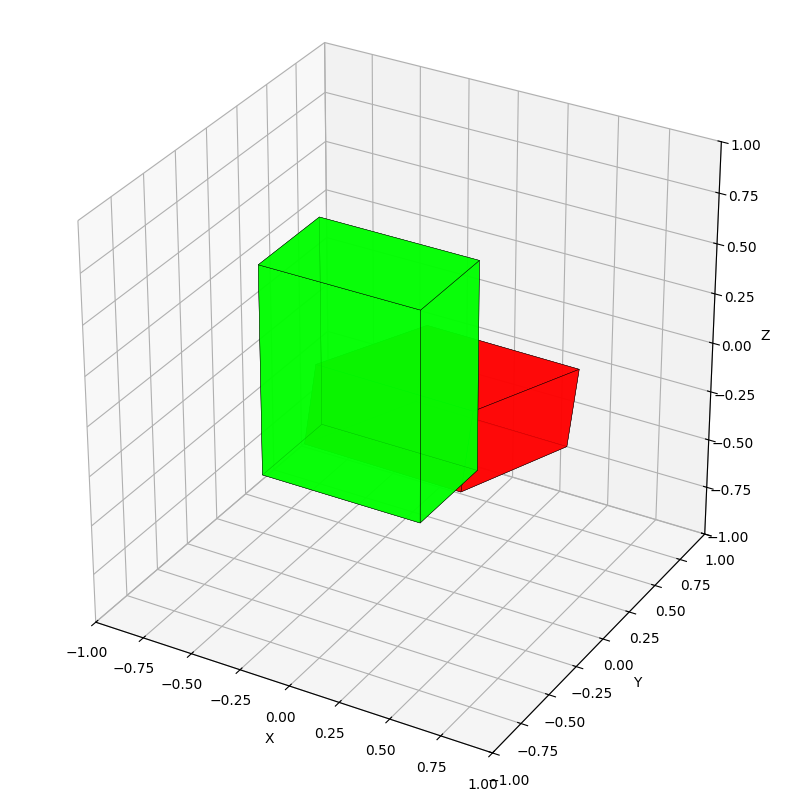

[SUCCESS] 3D plot displayed successfully.
[INFO] Expanding DSL tree for visualization...
[INFO] Expanding abstraction: Abs(Rotate, dim=3), compressed_params=[1.0729435682296753, -1.0560954809188843, -0.46023184061050415](
    Scale(lengths=[0.788, 0.499, 1.035])
        Box(label=1)
)
[SUCCESS] Reconstructed params: [0.002076171338558197, 7.852911949157715e-05, -0.001582309603691101, 1.0005347728729248]
[INFO] [INSTANTIATE] Pattern: 'Rotate' | params=[0.002076171338558197, 7.852911949157715e-05, -0.001582309603691101, 1.0005347728729248] | #children=1
[SUCCESS] Successfully rebuilt node: Rotate(quat=[0.0021, 0.0001, -0.0016, 1.0005])
    Scale(lengths=[0.788, 0.499, 1.035])
        Box(label=1)
[INFO] Expanding abstraction: Abs(Rotate, dim=3), compressed_params=[0.8282479047775269, -1.0506551265716553, -0.43467044830322266](
    Scale(lengths=[0.792, 1.014, 0.368])
        Box(label=0)
)
[SUCCESS] Reconstructed params: [-0.1354706883430481, 0.0006379187107086182, -0.000965312123298645,

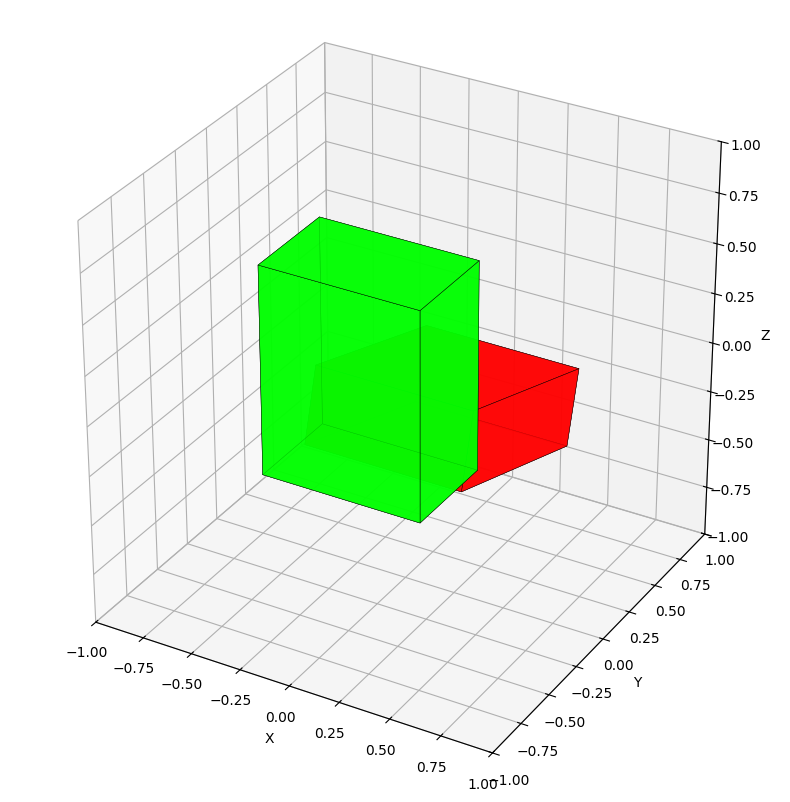

[SUCCESS] 3D plot displayed successfully.


In [22]:
import random

# --- Make sure your utility functions are available ---
# from abstractionssymh.abstraction_utils import integrate_abstractions
# from abstractionssymh.plot_utils import plot_dsl_with_matplotlib
# from abstractionssymh.debug_utils import debug_error, debug_success, debug_info

# Check that all necessary components (data and models) are loaded and ready
if all_dsl_shapes and singleton_models and pair_models:

    # --- 1. Select a Random Chair from the Dictionary ---
    # Get a list of all filenames (the dictionary keys)
    available_chair_names = list(all_dsl_shapes.keys())
    # Choose one at random
    random_chair_name = random.choice(available_chair_names)
    
    # Retrieve the DSL object using the random filename
    original_chair_dsl = all_dsl_shapes[random_chair_name]["dsl"]
    
    debug_info(f"--- Testing Abstraction on: {random_chair_name} ---")

    # --- 2. Run the Abstraction Process ---
    # This function walks the tree and replaces patterns with 'Abstraction' nodes
    abstracted_chair_dsl = integrate_abstractions(
        original_chair_dsl, 
        singleton_models, 
        pair_models, 
        error_threshold=0.01  # A stricter threshold for high-quality abstractions
    )

    # --- 3. Display Textual "Before and After" Comparison ---
    print("\n--- ORIGINAL CHAIR DSL ---")
    print(original_chair_dsl)
    
    print("\n--- ABSTRACTED CHAIR DSL ---")
    print(abstracted_chair_dsl)

    # --- 4. Generate Visual "Before and After" Comparison ---
    
    debug_info("\n--- Generating comparison plots... ---")
    
    # Define save paths for the comparison images
    comparison_dir = saved_directory / "abstraction_comparisons"
    original_save_path = comparison_dir / f"{random_chair_name.replace('.json', '_original.png')}"
    abstracted_save_path = comparison_dir / f"{random_chair_name.replace('.json', '_abstracted.png')}"
    
    # Plot and save the original chair
    # plot_dsl_with_matplotlib(original_chair_dsl, save_path=original_save_path)
    plot_dsl_with_matplotlib(original_chair_dsl)
    
    # Plot and save the abstracted chair (it should look identical)
    # plot_dsl_with_matplotlib(abstracted_chair_dsl, save_path=abstracted_save_path)
    plot_dsl_with_matplotlib(abstracted_chair_dsl)
    
else:
    debug_error("Cannot run the test: DSL shapes or trained models are missing.")

In [32]:
print(original_chair_dsl)

Union(
    Translate(center=[0.012, -0.328, 0.243])
        Rotate(quat=[0.0000, 0.0000, 0.0000, 1.0000])
            Scale(lengths=[0.788, 0.499, 1.035])
                Box(label=1),
    Translate(center=[0.012, 0.319, -0.268])
        Rotate(quat=[-0.1369, 0.0025, -0.0025, 0.9906])
            Scale(lengths=[0.792, 1.014, 0.368])
                Box(label=0)
)


In [33]:
print(abstracted_chair_dsl)

Union(
    Translate(center=[0.012, -0.328, 0.243])
        Abs(Rotate, dim=3), compressed_params=[1.0729435682296753, -1.0560954809188843, -0.46023184061050415](
            Scale(lengths=[0.788, 0.499, 1.035])
                Box(label=1)
        ),
    Translate(center=[0.012, 0.319, -0.268])
        Abs(Rotate, dim=3), compressed_params=[0.8282479047775269, -1.0506551265716553, -0.43467044830322266](
            Scale(lengths=[0.792, 1.014, 0.368])
                Box(label=0)
        )
)


In [34]:
from abstractionssymh.dsl_nodes import (
    Box,
    Scale,
    Rotate,
    Translate,
    Union,
    SymRef,
    SymRot,
    SymTrans,
)

In [35]:
print(abstracted_chair_dsl)

Union(
    Translate(center=[0.012, -0.328, 0.243])
        Abs(Rotate, dim=3), compressed_params=[1.0729435682296753, -1.0560954809188843, -0.46023184061050415](
            Scale(lengths=[0.788, 0.499, 1.035])
                Box(label=1)
        ),
    Translate(center=[0.012, 0.319, -0.268])
        Abs(Rotate, dim=3), compressed_params=[0.8282479047775269, -1.0506551265716553, -0.43467044830322266](
            Scale(lengths=[0.792, 1.014, 0.368])
                Box(label=0)
        )
)


In [36]:
pair_models.keys()

dict_keys(['Rotate(Scale)', 'Scale(Box)', 'Translate(Rotate)', 'Union(Translate)', 'SymRef(Translate)', 'SymRef(Union)', 'Union(SymRef)'])

In [37]:
singleton_models.keys()

dict_keys(['Rotate', 'Scale', 'Translate', 'SymRef'])

In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# ==============================================================================
# --- PART 1: DSL <-> DICTIONARY CONVERSION (Your working versions) ---
# ==============================================================================

def dsl_to_dict(node):
    """Converts your DSL node tree into a nested dictionary."""
    node_type = type(node).__name__
    if isinstance(node, Box):
        params = {"label": node.label}
        children = []
    elif isinstance(node, Scale):
        params = {"lengths": node.lengths.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Rotate):
        params = {"quaternion": node.quaternion.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Translate):
        params = {"center": node.center.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Union):
        params = {}
        children = [dsl_to_dict(node.left), dsl_to_dict(node.right)]
    elif isinstance(node, SymRef):
        params = {"plane": node.plane.tolist(), "point_on_plane": node.point_on_plane.tolist()}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, SymRot):
        params = {"axis": node.axis.tolist(), "center": node.center.tolist(), "n": node.n}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, SymTrans):
        params = {"end_point": node.end_point.tolist(), "n": node.n}
        children = [dsl_to_dict(node.child)]
    elif isinstance(node, Abstraction):
        params = {"pattern_name": node.pattern_name, "compressed_params": node.compressed_params}
        children = [dsl_to_dict(c) for c in node.children]
    else:
        params = {}
        children = []
    return {"type": node_type, "params": params, "children": children}

def dict_to_dsl(d, singleton_models=None, pair_models=None):
    """Converts a dictionary back into a DSL object using your trained models."""
    singleton_models = singleton_models or {}
    pair_models = pair_models or {}
    node_type = d["type"]
    params = d.get("params", {})
    children = [dict_to_dsl(c, singleton_models, pair_models) for c in d.get("children", [])]

    if node_type == "Abstraction":
        pattern_name = params.get("pattern_name")
        model = singleton_models.get(pattern_name) or pair_models.get(pattern_name)
        if model is None:
            raise ValueError(f"No trained model found for Abstraction '{pattern_name}'")
        return Abstraction(pattern_name, params["compressed_params"], model=model, children=children)
    elif node_type == "Box":
        return Box(params["label"])
    elif node_type == "Scale":
        return Scale(children[0], params["lengths"])
    elif node_type == "Rotate":
        return Rotate(children[0], params["quaternion"])
    elif node_type == "Translate":
        return Translate(children[0], params["center"])
    elif node_type == "SymRef":
        return SymRef(children[0], plane_normal=params["plane"], point_on_plane=params["point_on_plane"])
    elif node_type == "SymRot":
        return SymRot(children[0], axis=params["axis"], center=params["center"], n_fold=params["n"])
    elif node_type == "SymTrans":
        return SymTrans(children[0], end_point=params["end_point"], n_fold=params["n"])
    elif node_type == "Union":
        return Union(children[0], children[1])
    else:
        raise ValueError(f"Unknown node type in dict: {node_type}")

# ==============================================================================
# --- PART 2: THE NEW, INTUITIVE ACCORDION-ONLY WIDGET EDITOR ---
# ==============================================================================

live_output = widgets.Output()

def build_accordion_editor(data_source, update_fn):
    """
    (NEW) Recursively builds a clean, intuitive editor using only
    collapsible accordions and simple text boxes for parameters.
    """
    # --- 1. Parameter Widgets (using classic HBox with FloatText) ---
    param_widgets = []
    params_dict = data_source.get('params', {})
    for key, value in params_dict.items():
        hbox_items = [widgets.Label(value=f"{key}:", layout=widgets.Layout(width='140px'))]
        if isinstance(value, (int, float)):
            widget = widgets.FloatText(value=value, layout=widgets.Layout(width='100px'), step=0.01)
            def make_observer(source_dict, key):
                def on_value_change(change):
                    source_dict[key] = change.new
                    update_fn()
                return on_value_change
            widget.observe(make_observer(params_dict, key), names='value')
            hbox_items.append(widget)
        elif isinstance(value, list) and all(isinstance(v, (int, float)) for v in value):
            for i, num in enumerate(value):
                widget = widgets.FloatText(value=num, layout=widgets.Layout(width='100px'), step=0.01)
                def make_observer(source_list, index):
                    def on_value_change(change):
                        source_list[index] = change.new
                        update_fn()
                    return on_value_change
                widget.observe(make_observer(value, i), names='value')
                hbox_items.append(widget)
        else:
            hbox_items.append(widgets.Label(str(value)))
        param_widgets.append(widgets.HBox(hbox_items))
    
    param_box = widgets.VBox(param_widgets, layout=widgets.Layout(padding='5px 0 10px 0'))

    # --- 2. Children Node Widgets ---
    children_widgets = []
    children_list = data_source.get('children', [])
    for child_data in children_list:
        children_widgets.append(build_accordion_editor(child_data, update_fn))
    
    # --- 3. Assemble the Node Widget ---
    # Put parameters first, then the list of children widgets.
    node_content = widgets.VBox([param_box] + children_widgets)
    
    # Wrap the whole thing in a final Accordion for collapsibility.
    node_accordion = widgets.Accordion(children=[node_content])
    node_accordion.set_title(0, f"{data_source.get('type', 'Node')}")
    # Start with all nodes collapsed for a clean initial view.
    node_accordion.selected_index = None 
    
    return node_accordion

# ==============================================================================
# --- USAGE ---
# ==============================================================================

# Assume 'abstracted_chair_dsl' is your DSL object.
# Assume 'singleton_models' and 'pair_models' are your trained model dictionaries.

# 1. Convert DSL to dict
dsl_dict = dsl_to_dict(abstracted_chair_dsl)

# 2. Define the update function
def trigger_update():
    with live_output:
        clear_output(wait=True)
        # Rebuild DSL using your actual trained models
        new_dsl = dict_to_dsl(dsl_dict, singleton_models=singleton_models, pair_models=pair_models)
        plot_dsl_with_k3d(new_dsl) # Your plotting function

# 3. Build the new accordion-only editor
editor_widget = build_accordion_editor(dsl_dict, trigger_update)
editor_widget.layout = widgets.Layout(width='50%', border='1px solid #ddd', padding='5px')
live_output.layout = widgets.Layout(width='50%', padding='10px')

# 4. Display in a side-by-side layout
print("Interactive DSL Editor and Live View")
display(widgets.HBox([editor_widget, live_output]))
trigger_update()


Interactive DSL Editor and Live View


In [ ]:
# debug_info("Starting singleton model training...")
# singleton_models = find_abstractions(singleton_params, structure_type="SINGLETONS", min_examples=50, epochs=25)

# debug_info("Starting pair model training...")
# pair_models = find_abstractions(pair_params, structure_type="PAIRS", min_examples=50, epochs=25)

# debug_success(f"Training complete. {len(singleton_models)} singleton models and {len(pair_models)} pair models trained.")

In [ ]:
# if all_dsl_shapes and singleton_models and pair_models:
#     random_chair = random.choice(all_dsl_shapes)
#     # debug_info("--- ORIGINAL CHAIR ---")
#     # debug_info(f"Serialized children count: {len(random_chair.serialize()[1][1])}")
#     # debug_info(f"Preview: {random_chair}")

#     abstracted_chair = integrate_abstractions(
#         random_chair, singleton_models, pair_models, error_threshold=0.01
#     )

#     # debug_info("\n--- ABSTRACTED CHAIR ---")
#     # if isinstance(abstracted_chair, Abstraction):
#     #     debug_info(f"Abstraction pattern: {abstracted_chair.pattern_name}, compressed dim: {len(abstracted_chair.compressed_params)}")
#     # debug_info(f"Preview: {abstracted_chair}")

#     # Visualization
#     # plot_chair(random_chair)
#     # plot_chair(abstracted_chair)
# else:
#     debug_error("Cannot run test: DSL shapes or trained models are missing.")

In [ ]:
# print("Original Chair Object:")
# print(random_chair)

# print("\nAbstracted Chair Object:")
# print(abstracted_chair)

In [ ]:
# import pandas as pd
# from tqdm.notebook import tqdm

# from abstractionssymh.abstraction_compare_utils import calculate_tree_complexity_reduction, calculate_parameter_compression, calculate_abstraction_coverage
# from abstractionssymh.abstraction_compare_utils import get_point_cloud_from_dsl, calculate_chamfer_distance, plot_point_clouds_with_k3d

# all_results_with_objects = []

# # Loop through all shapes with a progress bar
# for i, original_chair in enumerate(tqdm(all_dsl_shapes[:1000], desc="Processing and Storing Chairs")):
    
#     # 1. Perform the abstraction
#     abstracted_chair = integrate_abstractions(
#         original_chair, singleton_models, pair_models, error_threshold=0.01
#     )
    
#     # 2. Calculate metrics
#     complexity = calculate_tree_complexity_reduction(original_chair, abstracted_chair)
#     compression = calculate_parameter_compression(original_chair, abstracted_chair)
#     coverage = calculate_abstraction_coverage(original_chair, abstracted_chair)

#     pc_original = get_point_cloud_from_dsl(original_chair, points_per_box=1000)
#     pc_abstracted = get_point_cloud_from_dsl(abstracted_chair, points_per_box=1000)
#     chamfer_distance = calculate_chamfer_distance(pc_original, pc_abstracted)
    
#     # 3. Store metrics AND the actual DSL objects
#     chair_result = {
#         'chair_id': i,
#         # --- Metrics ---
#         'node_reduction_%': float(complexity['metrics']['node_count_reduction'].strip('%')),
#         'depth_reduction_%': float(complexity['metrics']['max_depth_reduction'].strip('%')),
#         'param_compression_%': float(compression['metrics']['parameter_compression_ratio'].strip('%')),
#         'abstraction_coverage_%': float(coverage['metrics']['abstraction_coverage'].strip('%')),
#         'chamfer_distance': float(chamfer_distance),
#         # --- ADDING THE DSL OBJECTS ---
#         'original_chair_obj': original_chair,
#         'abstracted_chair_obj': abstracted_chair
#     }
    
#     all_results_with_objects.append(chair_result)

# print(f"\nProcessed and stored {len(all_results_with_objects)} chairs with their objects and metrics.")

# # --- Create the DataFrame ---
# # The DataFrame will now have columns containing the chair objects themselves.
# results_df_with_objects = pd.DataFrame(all_results_with_objects)

# # Display the DataFrame columns to confirm objects are stored
# print("\nDataFrame columns:", results_df_with_objects.columns.tolist())
# display(results_df_with_objects.head())

In [ ]:
# results_df_with_objects.to_csv(saved_directory / Path("full_abstraction_results.csv"))

In [ ]:
# results_df_with_objects.to_pickle(saved_directory / Path("full_abstraction_results.pkl"))

In [ ]:
# import pandas as pd

# # --- LOADING THE RESULTS ---
# # Load the entire DataFrame, including the DSL objects, back from the pickle file
# loaded_results_df = pd.read_pickle("full_abstraction_results.pkl")

# print("Successfully loaded the results DataFrame.")
# print("Columns:", loaded_results_df.columns.tolist())
# display(loaded_results_df.head())

# # Now you can access the objects just like before
# a_random_chair = loaded_results_df.sample().iloc[0]
# original_obj = a_random_chair['original_chair_obj']

# print("\nSuccessfully accessed a loaded DSL object:")
# print(original_obj)

In [ ]:
# # --- Find the chair with the highest abstraction coverage ---
# # We use idxmax() to get the index of the row with the maximum value in that column.
# # best_chair_index = results_df_with_objects['abstraction_coverage_%'].idxmax()
# best_chair_index = results_df_with_objects.sample().index[0]

# # --- Retrieve the entire row for that chair ---
# best_chair_data = results_df_with_objects.loc[best_chair_index]

# print(f"--- Inspecting Chair ID: {best_chair_data['chair_id']} (Abstraction: {best_chair_data['abstraction_coverage_%']:.2f}%) ---\n")

# # --- Access the stored objects from the DataFrame row ---
# chair_to_compare_original = best_chair_data['original_chair_obj']
# chair_to_compare_abstracted = best_chair_data['abstracted_chair_obj']

# # --- Now you can compare them directly ---

# # 1. Print the structures to see the code-level difference
# print("--- ORIGINAL CHAIR STRUCTURE ---")
# print(chair_to_compare_original)
# print("\n--- ABSTRACTED CHAIR STRUCTURE ---")
# print(chair_to_compare_abstracted)

# # 2. Plot them both to visually confirm they are identical
# print("\n--- VISUAL COMPARISON ---")
# print("Displaying Original Chair Plot:")
# plot_chair(chair_to_compare_original)

# print("Displaying Abstracted Chair Plot:")
# plot_chair(chair_to_compare_abstracted)